# Licensed Premises Variable Construction

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [2]:
# ── Load licensed-premises data ──────────────────────────────────────────
premises_raw = pd.read_csv("Glasgow_Alc_Premise.csv")
print(f"Raw premises: {len(premises_raw)}")
print(premises_raw["ALCOHOL_SALES"].value_counts())

# Keep only premises licensed for ON-sales (bars, pubs, restaurants, clubs)
on_mask = premises_raw["ALCOHOL_SALES"].isin(["On", "On & Off"])
premises = premises_raw.loc[on_mask].copy()
print(f"\nOn-sales premises retained: {len(premises)}")

# X and Y are already British National Grid (EPSG:27700) eastings/northings
premises_gdf = gpd.GeoDataFrame(
    premises,
    geometry=gpd.points_from_xy(premises["X"], premises["Y"]),
    crs="EPSG:27700",
)
print(f"Null geometries: {premises_gdf.geometry.is_empty.sum()}")
premises_gdf.head()

Raw premises: 1902
ALCOHOL_SALES
On & Off    719
Off         596
On          587
Name: count, dtype: int64

On-sales premises retained: 1306
Null geometries: 0


,X,Y,OBJECTID,ALCOHOL_SALES,LICENCE_NO,PREMISES_REF,LICENCE_HOLDER,PREMISES_MANAGER,GRANTDATE,CHILDREN,...,UPRN,DISTANCE,ADDRESS,LOG_STATUS,AREANAME,AREACODE,WARDNO,WARDNAME,INTERZONE,geometry
1,254262.84,665031.08,2,On,GC0007,Drumoyne Bowling Club 9 Drumoyne Square Glasgo...,Drumoyne Bowling Club,NaN,2008/06/02 00:00:00+00,NaN,...,906700155961,NaN,9 Drumoyne Square Glasgow G51 4BG,NaN,Greater Govan,1,5,Govan,S02001855,POINT (254262.84 665031.08)
2,259384.00,665144.00,3,On & Off,GC0008,Poko Loko 69 Hutcheson Street Glasgow G1 1SH,Manorview Partnerships Limited,Stuart Douglas Kay,2008/06/02 00:00:00+00,NaN,...,906700056361,NaN,69 Hutcheson Street Glasgow G1 1SH,NaN,City Centre / Merchant City,29,10,Anderston/City/Yorkhill,S02001932,POINT (259384 665144)
4,258390.00,665898.00,5,On & Off,GC0014,303 Sauchiehall Street Glasgow G2 3HQ,Chinatown Investments (303) Limited,Quinnan Desmond Lee,2008/06/02 00:00:00+00,NaN,...,906700095710,NaN,299 Sauchiehall Street Glasgow G2 3HQ,NaN,City Centre / Merchant City,29,10,Anderston/City/Yorkhill,S02001933,POINT (258390 665898)
7,258298.00,662564.00,8,On & Off,GC0021,The Bell Jar 21 Dixon Avenue Glasgow G42 8EB,Barlington House Limited,Sophie Diviney,2008/06/02 00:00:00+00,NaN,...,906700253223,NaN,21 Dixon Avenue Glasgow G42 8EB,NaN,Govanhill,4,8,Southside Central,S02001868,POINT (258298 662564)
8,257955.00,662741.00,9,On & Off,GC0024,Heraghty's Bar 708 Pollokshaws Road Glasgow G4...,The Firm of Heraghty's Bar,Laurence Welch,2008/06/02 00:00:00+00,NaN,...,906700301403,NaN,708 Pollokshaws Road Glasgow G41 2AD,NaN,Shawlands / Strathbungo,6,6,Pollokshields,S02001868,POINT (257955 662741)


In [3]:
# ── Load station locations ────────────────────────────────────────────────
STATIONS_PATH = "glasgow_stations.csv"   # same file used in CensusFix.ipynb

stations = pd.read_csv(STATIONS_PATH)
stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lon"], stations["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=27700)

print(f"Stations loaded: {len(stations_gdf)}")
stations_gdf[["station_id", "geometry"]].head()

Stations loaded: 121


,station_id,geometry
0,Duke Street Railway Station,POINT (261552.613 664997.164)
1,Langside Hall - ELECTRIC,POINT (257391.318 662166.984)
2,Springfield Quay 2,POINT (257703.004 664695.322)
3,Glasgow Green,POINT (260252.159 664061.917)
4,Carrick Quay,POINT (259151.577 664689.037)


In [4]:
def count_premises_in_buffers(stations_gdf, premises_gdf,
                              buffer_distances_m,
                              station_id_col="station_id"):
    """
    For each buffer distance, counts the number of on-sales premises
    and sums their on-premises capacity within that radius of each station.

    Returns a long DataFrame: [station_id, buffer_m, n_on_premises, total_capacity_on]
    """
    records = []

    for buf in buffer_distances_m:
        # Buffer each station
        buffered = stations_gdf[[station_id_col, "geometry"]].copy()
        buffered["geometry"] = buffered.geometry.buffer(buf)

        # Spatial join: which premises fall within each station buffer?
        joined = gpd.sjoin(
            premises_gdf[["geometry", "CAPACITY_ON"]],
            buffered,
            predicate="within",
            how="inner",
        )

        # Aggregate per station
        agg = (
            joined
            .groupby(station_id_col)
            .agg(
                n_on_premises=("CAPACITY_ON", "size"),
                total_capacity_on=("CAPACITY_ON", "sum"),
            )
            .reset_index()
        )

        # Ensure every station appears (fill zeros for stations with no premises nearby)
        all_stations = stations_gdf[[station_id_col]].copy()
        agg = all_stations.merge(agg, on=station_id_col, how="left")
        agg[["n_on_premises", "total_capacity_on"]] = (
            agg[["n_on_premises", "total_capacity_on"]].fillna(0)
        )
        agg["n_on_premises"] = agg["n_on_premises"].astype(int)

        agg["buffer_m"] = buf
        records.append(agg)

    return pd.concat(records, ignore_index=True)

In [ ]:
## Match buffers
BUFFER_DISTANCES_M = [150, 250, 500, 750]

premises_by_station = count_premises_in_buffers(
    stations_gdf, premises_gdf,
    buffer_distances_m=BUFFER_DISTANCES_M,
    station_id_col="station_id",
)

print(premises_by_station.shape)
premises_by_station.head(12)

(484, 4)


,station_id,n_on_premises,total_capacity_on,buffer_m
0,Duke Street Railway Station,5,620.0,150
1,Langside Hall - ELECTRIC,11,2181.0,150
2,Springfield Quay 2,6,4260.0,150
3,Glasgow Green,0,0.0,150
4,Carrick Quay,6,884.0,150
5,St Andrews Drive @ Maxwell Drive,0,0.0,150
6,Partick Interchange,2,231.0,150
7,Merchant Square - ELECTRIC,44,13700.0,150
8,Argyle Street Railway Station - ELECTRIC,10,5593.0,150
9,Bellgrove Railway Station (North) - ELECTRIC,1,75.0,150


In [ ]:
# ── Summary stats per buffer radius
summary = (
    premises_by_station
    .groupby("buffer_m")["n_on_premises"]
    .describe()
    .round(1)
)
print(summary)
print("\nStations with zero on-premises at each buffer:")
print(
    premises_by_station
    .groupby("buffer_m")["n_on_premises"]
    .apply(lambda s: (s == 0).sum())
)

          count  mean    std  min   25%   50%    75%    max
buffer_m                                                   
150       121.0   5.2    8.7  0.0   0.0   2.0    6.0   45.0
250       121.0  12.9   21.2  0.0   1.0   4.0   13.0  104.0
500       121.0  43.3   67.7  0.0   5.0  14.0   46.0  294.0
750       121.0  86.8  115.8  0.0  11.0  30.0  102.0  418.0

Stations with zero on-premises at each buffer:
buffer_m
150    36
250    17
500     8
750     2
Name: n_on_premises, dtype: int64


In [ ]:
# ── Export 
OUT_PATH = "station_on_premises.csv"
premises_by_station.to_csv(OUT_PATH, index=False)
print(f"Saved to {OUT_PATH}")
premises_by_station.sample(8)

Saved to station_on_premises.csv


,station_id,n_on_premises,total_capacity_on,buffer_m
225,London Road Central,5,856.0,250
340,St Andrews Drive - Dalziel Drive,0,0.0,500
77,Clifton St / Kelvingrove Park East,0,0.0,150
36,Glasgow Forge (Gallowgate),1,60.0,150
389,Queens Park Railway Station - ELECTRIC,37,6255.0,750
53,St George's Cross - ELECTRIC,2,88.0,150
169,Trongate,36,6992.0,250
8,Argyle Street Railway Station - ELECTRIC,10,5593.0,150


### Quick visual check
Map the 250 m count to sanity-check spatial distribution.

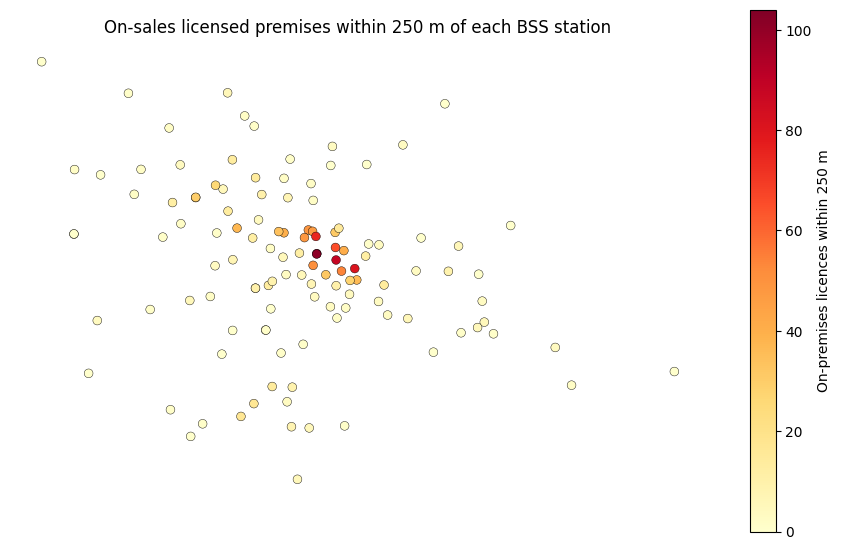

In [8]:
import matplotlib.pyplot as plt

buf_250 = premises_by_station[premises_by_station["buffer_m"] == 250].copy()
buf_250 = stations_gdf[["station_id", "geometry"]].merge(buf_250, on="station_id")
buf_250 = gpd.GeoDataFrame(buf_250, geometry="geometry", crs="EPSG:27700")

fig, ax = plt.subplots(figsize=(9, 9))
buf_250.plot(
    column="n_on_premises",
    cmap="YlOrRd",
    markersize=40,
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    legend_kwds={"label": "On-premises licences within 250 m", "shrink": 0.6},
)
ax.set_axis_off()
ax.set_title("On-sales licensed premises within 250 m of each BSS station", fontsize=12)
plt.tight_layout()
plt.savefig("map_on_premises_250m.png", dpi=200)
plt.show()